In [ ]:
pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.6/31.6 MB 25.9 MB/s eta 0:00:00


In [ ]:
pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import qutip as qt
from scipy.optimize import minimize
import qiskit.visualization as qv
from qiskit.quantum_info import DensityMatrix
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def rotate_bell_state(pauli_matrix, state):
    """
    Ruota uno stato quantistico utilizzando una matrice di Pauli.
    Args:
        pauli_matrix (Qobj): La matrice di Pauli usata per la rotazione.
        state (Qobj): Lo stato quantistico da ruotare.
    Returns:
        Qobj: Lo stato ruotato.
    """
    return pauli_matrix * state

def fidelity_to_minimize(params, bell_state, rho_exp):
    """
    Funzione da minimizzare: -fidelità tra lo stato ruotato e la matrice densità sperimentale.
    Args:
        params (list): [c, c_x, c_y, c_z]
        bell_state (Qobj): Stato di Bell.
        rho_exp (Qobj): Matrice densità sperimentale.
    Returns:
        float: Valore negativo della fidelità.
    """
    c, c_x, c_y, c_z = params
    pauli_x = qt.tensor(qt.sigmax(), qt.qeye(2))
    pauli_y = qt.tensor(qt.sigmay(), qt.qeye(2))
    pauli_z = qt.tensor(qt.sigmaz(), qt.qeye(2))
    ide = qt.tensor(qt.qeye(2), qt.qeye(2))

    rotation_operator = 1j * c_x * pauli_x + 1j * c_y * pauli_y + 1j * c_z * pauli_z + c * ide
    rotated_state = rotate_bell_state(rotation_operator, bell_state)
    fidelity = (rotated_state.dag() * rho_exp * rotated_state)

    return -np.sqrt((np.abs(fidelity) ** 2))

rho_exp = qt.Qobj([[ 0.41410175-9.08675219e-19j,  0.04232247+1.81670257e-01j,
         0.12585777+1.61939734e-01j,  0.15500237-3.21588577e-01j],
       [ 0.04232247-1.81670257e-01j,  0.12151567-2.50335062e-18j,
         0.1125074 -5.90244577e-02j, -0.14199165-1.15692311e-01j],
       [ 0.12585777-1.61939734e-01j,  0.1125074 +5.90244577e-02j,
         0.13804591+6.46583090e-18j, -0.08624324-1.75510564e-01j],
       [ 0.15500237+3.21588577e-01j, -0.14199165+1.15692311e-01j,
        -0.08624324+1.75510564e-01j,  0.32633668-3.05380506e-18j]], dims=[[2, 2], [2, 2]])

rho_exp_qiskit = DensityMatrix(rho_exp.full())
fig = qv.plot_state_city(rho_exp_qiskit.data, color=['coral', 'deepskyblue'])

for ax in fig.get_axes():
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label, ax.zaxis.label] +
                 ax.get_xticklabels() + ax.get_yticklabels() + ax.get_zticklabels()):
        item.set_fontsize(8)

plt.show()

bell_state = qt.bell_state('00')
fide1 = bell_state.dag() * rho_exp * bell_state
print("Initial fidelity:", np.sqrt((np.abs(fide1) ** 2)))

initial_params = np.array([0.4, -0.3, -0.45, -0.8]) / np.sqrt(4)
constraints = ({'type': 'eq', 'fun': lambda params: np.sum(np.abs(params) ** 2) - 1})

result = minimize(fidelity_to_minimize, initial_params, args=(bell_state, rho_exp),
                  method='SLSQP', constraints=constraints, options={'disp': True})

optimal_params = result.x
c_opt, c_x_opt, c_y_opt, c_z_opt = optimal_params

print("Optimal parameters:")
print(f"c: {c_opt}, c_x: {c_x_opt}, c_y: {c_y_opt}, c_z: {c_z_opt}")

fidelity = -result.fun
print("Fidelity with optimal parameters:", fidelity)
print("c_x^2 + c_y^2 + c_z^2 + c^2 =", (np.abs(c_opt)**2 + np.abs(c_x_opt)**2 +
                                        np.abs(c_y_opt)**2 + np.abs(c_z_opt)**2))

pauli_x = qt.tensor(qt.sigmax(), qt.qeye(2))
pauli_y = qt.tensor(qt.sigmay(), qt.qeye(2))
pauli_z = qt.tensor(qt.sigmaz(), qt.qeye(2))
ide = qt.tensor(qt.qeye(2), qt.qeye(2))

rotation_operator = 1j * c_x_opt * pauli_x + 1j * c_y_opt * pauli_y + 1j * c_z_opt * pauli_z + c_opt * ide
rho_rotated = rotation_operator.dag() * rho_exp * rotation_operator

rho_rotated_qiskit = DensityMatrix(rho_rotated.full())
fig = qv.plot_state_city(rho_rotated_qiskit.data, color=['coral', 'deepskyblue'])

for ax in fig.get_axes():
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label, ax.zaxis.label] +
                 ax.get_xticklabels() + ax.get_yticklabels() + ax.get_zticklabels()):
        item.set_fontsize(8)

plt.show()


Initial fidelity: 0.525221585
Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.9411675246224398
            Iterations: 7
            Function evaluations: 36
            Gradient evaluations: 7
Optimal parameters:
c: 0.7396049438149607, c_x: -0.47632043988132644, c_y: -0.10613798366056483, c_z: -0.4635065741681711
Fidelity with optimal parameters: 0.9411675246224398
c_x^2 + c_y^2 + c_z^2 + c^2 = 1.000000250236916


In [ ]:
rho_rotated_qiskit

DensityMatrix([[ 0.52185872+2.77555756e-17j, -0.0235965 +5.14940277e-03j,
                -0.0191831 -1.83908814e-02j,  0.46389796+1.36374772e-06j],
               [-0.0235965 -5.14940277e-03j,  0.01517206+5.85469173e-18j,
                 0.01866758+8.76230698e-03j, -0.01590427-1.42485978e-02j],
               [-0.0191831 +1.83908814e-02j,  0.01866758-8.76230698e-03j,
                 0.03028908+3.46944695e-18j, -0.02032428+1.01029177e-03j],
               [ 0.46389796-1.36374772e-06j, -0.01590427+1.42485978e-02j,
                -0.02032428-1.01029177e-03j,  0.4326804 +0.00000000e+00j]],
              dims=(2, 2))


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from qiskit.visualization import plot_state_city

fig = qv.plot_state_city(rho_rotated_qiskit.data, color=['coral', 'deepskyblue'])

for ax in fig.get_axes():
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label, ax.zaxis.label] +
                 ax.get_xticklabels() + ax.get_yticklabels() + ax.get_zticklabels()):
        item.set_fontsize(8)

plt.show()


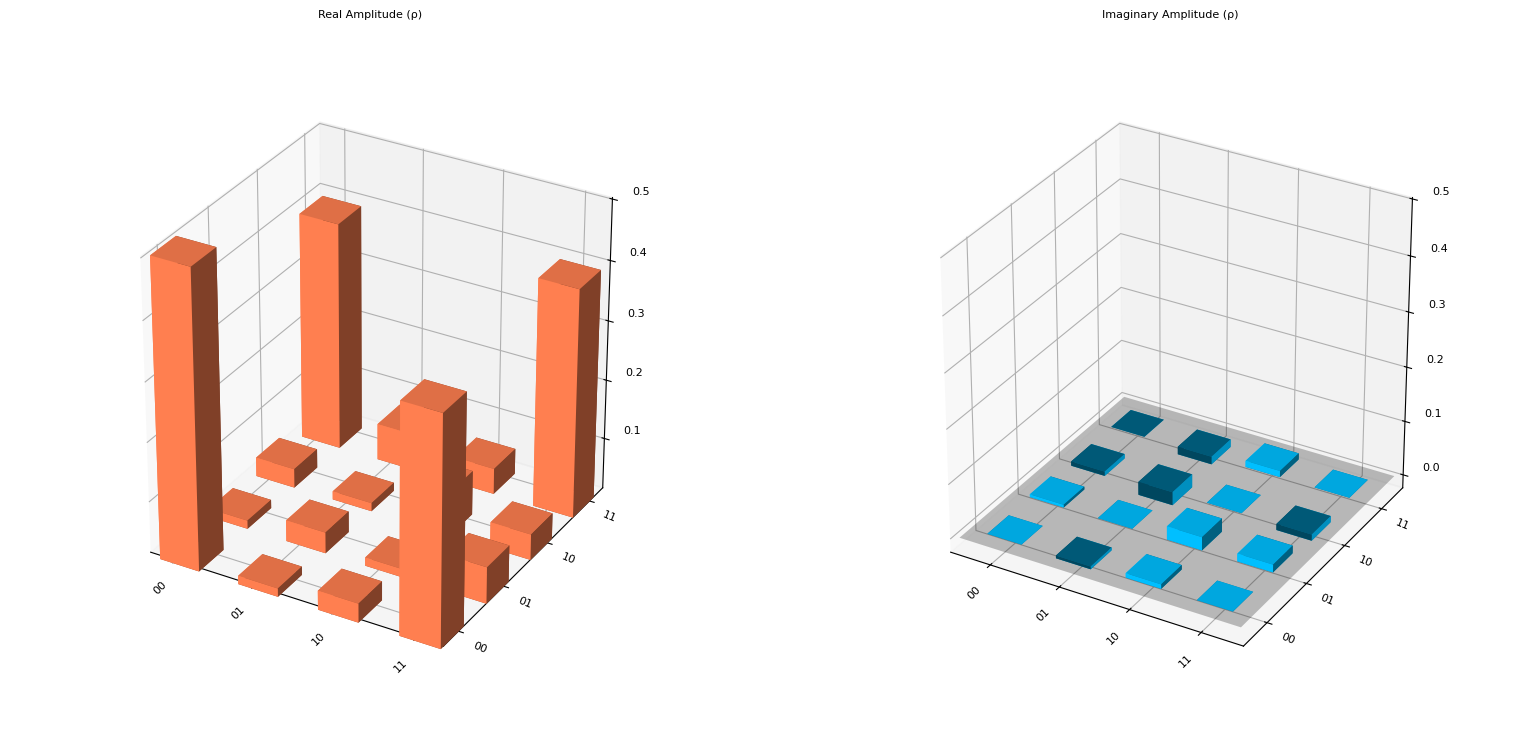

In [ ]:
from IPython.display import display

display(fig)
